Part A: Setting up the directory, packages, and environment for the datasets



In [1]:
import os

# Set this to the folder containing your CSV files
DATA_DIR = r'C:\Users\tthem\timeseries-april\data'

In [ ]:
# Import the packages

# ! pip install pandas numpy matplotlib datetime statsmodels scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------  9.7/9.9 MB 51.8 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 34.9 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 12.4/12.4 MB 64.2 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 60.4 MB/s  0:00:00
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 9.6/9.6 MB 69.7 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------------------- -------------------- 18.4/37.3 MB 91.4 MB/s eta 0:00:01
   -------------------------------------- - 36.2/37.3 MB 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import zscore

Part B: Downloading the datasets

In [3]:
df_holidays = pd.read_csv(os.path.join(DATA_DIR, 'holidays.csv'))
display(df_holidays.head())

,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [4]:
df_stores = pd.read_csv(os.path.join(DATA_DIR, 'stores.csv'))
display(df_stores.head())

,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


In [5]:
df_oil = pd.read_csv(os.path.join(DATA_DIR, 'oil.csv'))
display(df_oil.head())

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [6]:
df_timeseries = pd.read_csv(os.path.join(DATA_DIR, 'timeseries.csv'))
display(df_timeseries.head())

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


Part C: Exploratory Data Analysis

df_holidays head:


,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba



Visualizing df_holidays data:


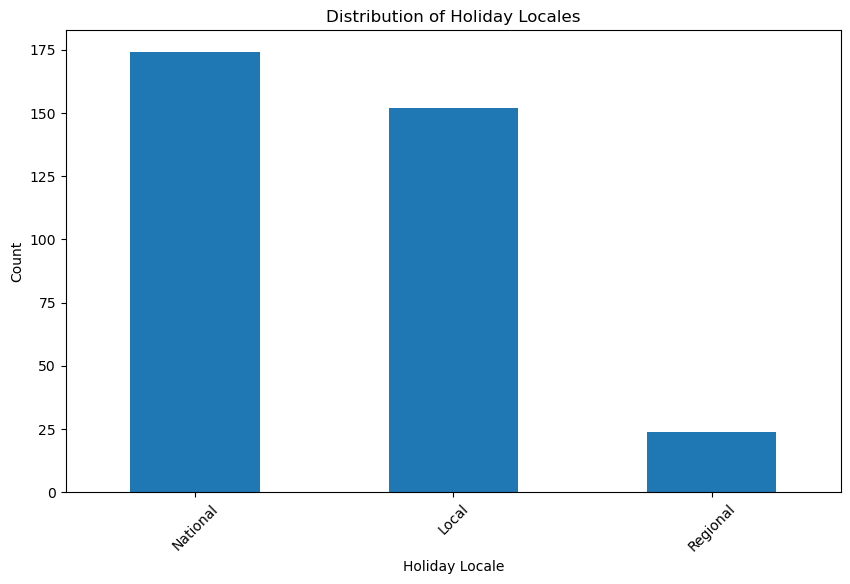

In [7]:
print("df_holidays head:")
display(df_holidays.head())

print("\nVisualizing df_holidays data:")
# Bar plot for holiday types
plt.figure(figsize=(10, 6))
df_holidays['locale'].value_counts().plot(kind='bar')
plt.title('Distribution of Holiday Locales')
plt.xlabel('Holiday Locale')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

df_stores head:


,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


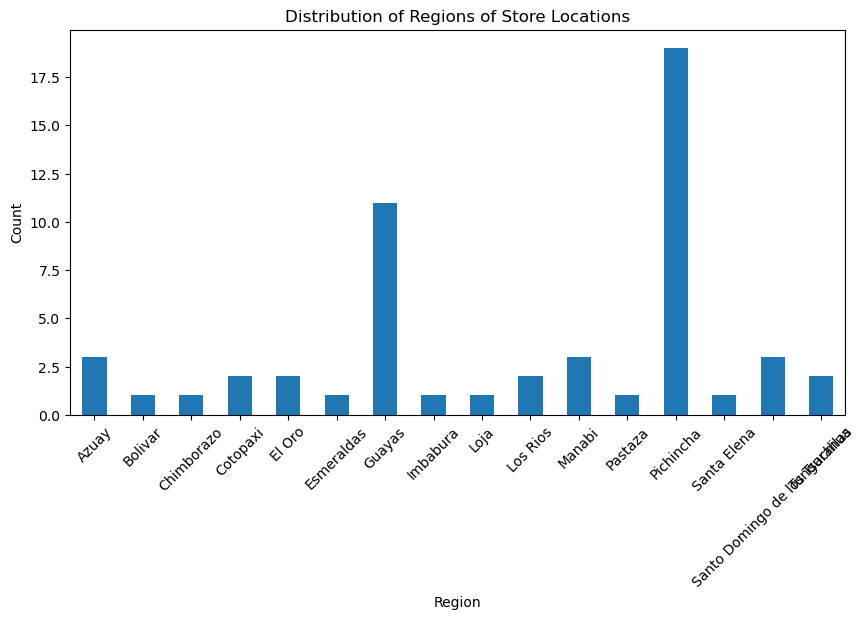

In [8]:
print("df_stores head:")
display(df_stores.head())

# Bar plot for store clusters
plt.figure(figsize=(10, 5))
df_stores['region'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Regions of Store Locations')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

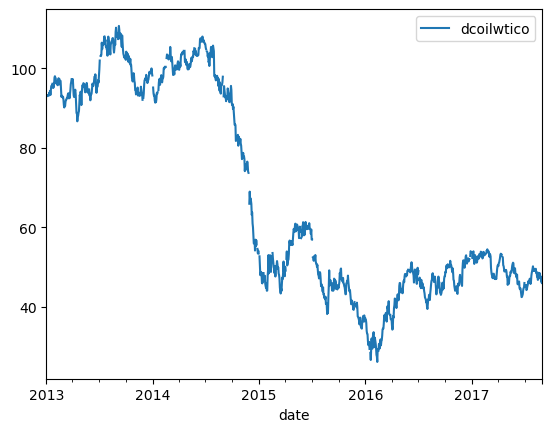

In [9]:
# Oil dataset - Convert date format and plotted the line graph
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil.plot(x='date', y='dcoilwtico')
plt.show()

In [10]:
# Oil dataset
# Impute missing values in the 'dcoilwtico' column of df_oil using linear interpolation
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].interpolate(method='linear')

# Display the head of the DataFrame to show the changes and check for remaining NaNs
print("DataFrame head after interpolation:")
display(df_oil.head())

# Check if there are any remaining NaNs in the 'dcoilwtico' column
print("Number of missing values in 'dcoilwtico' after interpolation:", df_oil['dcoilwtico'].isnull().sum())

DataFrame head after interpolation:


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


Number of missing values in 'dcoilwtico' after interpolation: 1


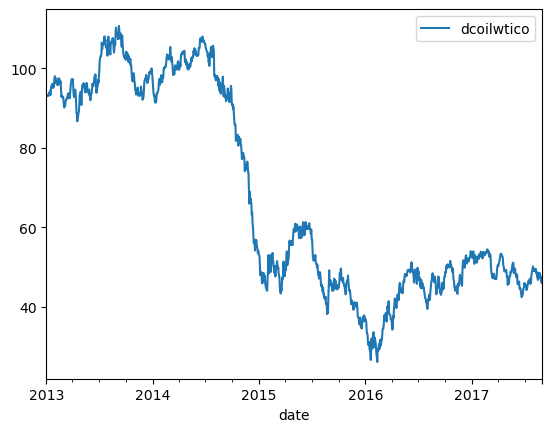

In [11]:
# Oil dataset - Let's check it again to see if the values were filled
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil.plot(x='date', y='dcoilwtico')
plt.show()

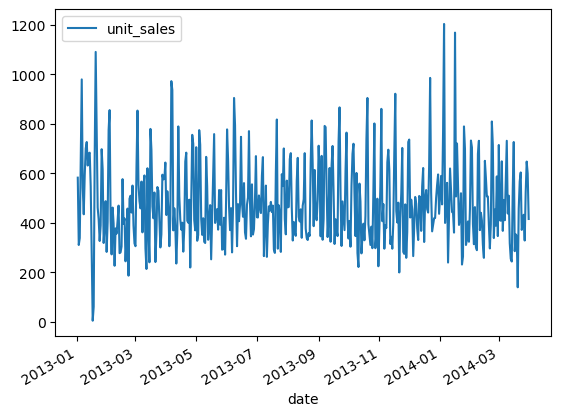

In [12]:
# Time Series dataset - Convert date format and plotted the line graph
df_timeseries['date'] = pd.to_datetime(df_timeseries['date'])
df_timeseries.plot(x='date', y='unit_sales')
plt.show()

In [13]:
# Time Series dataset - Use ADF test function to check if it is stationarity (H0 = non-stationary vs. H1 = stationary)
def run_adf(timeseries):
    """Performs Augmented Dickey-Fuller test on a given time series."""
    adf_result = adfuller(timeseries)
    p_value = adf_result[1]
    print(f'P-value is {p_value}')
    if p_value <= 0.05:
        print("The series is stationary (reject H0).")
    else:
        print("The series is non-stationary (fail to reject H0).")

In [14]:
# Time Series dataset - Test stationarity on original series
run_adf(df_timeseries['unit_sales'])

P-value is 1.4530177416878616e-05
The series is stationary (reject H0).


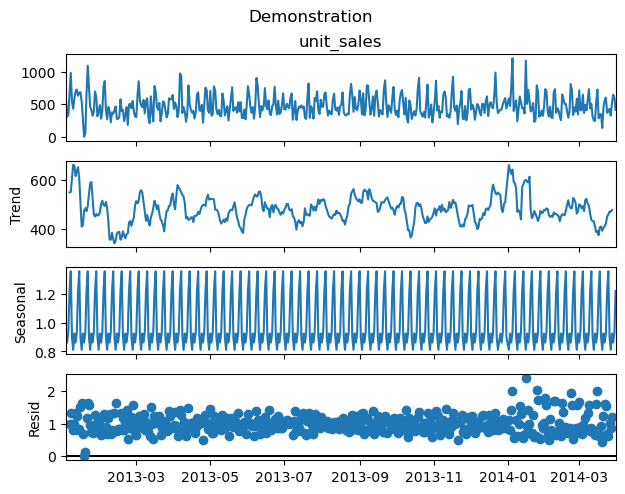

In [15]:
# Time Series dataset - Decompose the time series into Trend × Seasonality × Residual (multiplicative model)
df_timeseries_indexed = df_timeseries.set_index('date')
decomp_mul = seasonal_decompose(df_timeseries_indexed['unit_sales'], model="multiplicative", period=7)
decomp_mul.plot()
plt.suptitle("Demonstration", y=1.02)
plt.show()

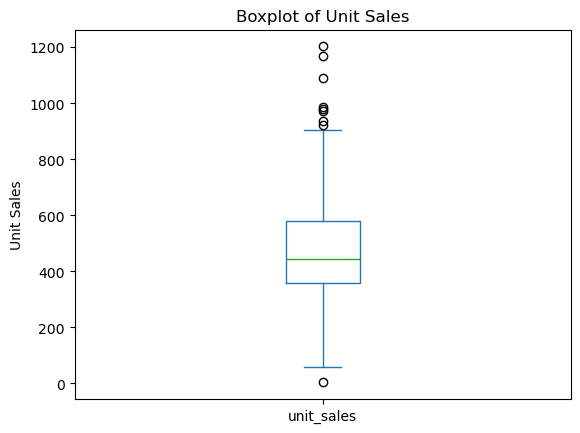

In [16]:
# Time Series dataset - Detecting Outliers with a Boxplot
df_timeseries.plot.box(y='unit_sales', title='Boxplot of Unit Sales')
plt.ylabel('Unit Sales')
plt.show()

In [17]:
# Time Series dataset -Calculate Z-scores for the 'unit_sales' column to provide a statistical measure for outliers
df_timeseries['unit_sales_zscore'] = zscore(df_timeseries['unit_sales'])

# Display the head of the DataFrame with the new Z-score column
print("DataFrame head with Z-scores:")
display(df_timeseries.head())

DataFrame head with Z-scores:


,date,unit_sales,unit_sales_zscore
0,2013-01-02,582.0,0.597181
1,2013-01-03,310.0,-0.996719
2,2013-01-04,338.0,-0.832641
3,2013-01-05,654.0,1.019095
4,2013-01-06,979.0,2.923570


<Figure size 1200x600 with 0 Axes>

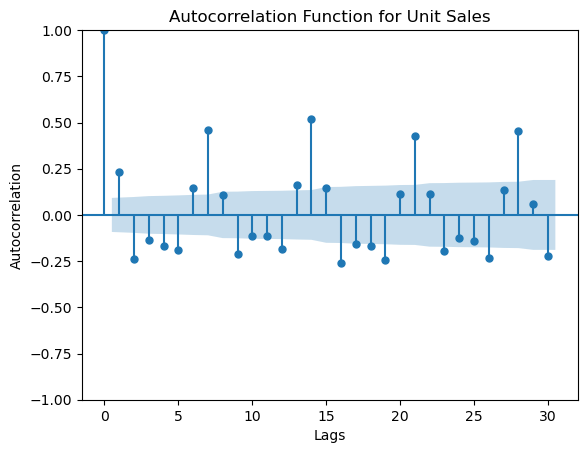

In [18]:
# Time Series dataset - Create an autocorrelation plot for 'unit_sales'
plt.figure(figsize=(12, 6))
plot_acf(df_timeseries['unit_sales'], lags=30)
plt.title('Autocorrelation Function for Unit Sales')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()